# 09 — Robustez do parsing de citações processuais e reparo N2

Rodada exploratória final, determinística e *oracle-only* sobre processos CNJ e processos/recursos numerados. O notebook não consulta SQLite, `CaseIndex` ou `id_canonico`, e não altera código de produção.

## 1. Dados, spans-oráculo e baseline do Notebook 08

A baseline é reproduzida antes de qualquer tolerância. `numero_raw` sempre preserva o trecho original; qualquer forma comparável é registrada apenas em `numero_normalizado`.

In [1]:
from __future__ import annotations

import hashlib
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', 110)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
TEXT_DIR, GOLDENSET_PATH, DB_PATH = DATASET_DIR / 'txt', DATASET_DIR / 'goldenset.xlsx', DATASET_DIR / 'desafio1_bracis.db'

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

db_sha_before = sha256_file(DB_PATH)
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl').reset_index(names='gold_idx')
gold['nivel'] = 'N' + gold['nivel'].astype(str).str.removeprefix('N')
gold['inicio'], gold['fim'] = gold['inicio'].astype(int), gold['fim'].astype(int)
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
gold['oracle_span'] = gold.apply(lambda row: texts[row.documento_id][row.inicio:row.fim], axis=1)
gold['trecho_esperado'] = gold['trecho'].astype(str).str.replace(r'\n', '\n', regex=False)
assert len(texts) == 26 and len(gold) == 225 and gold.oracle_span.eq(gold.trecho_esperado).all()

CNJ_PATTERN = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
PROCESS_CLASS_PATTERN = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
NUMBERED_CASE_PATTERN = re.compile(r'(?P<classe>(?:(?:AgInt|AgRg|EDcl|ED)\s+(?:no|n[oº.]+)\s+)?(?:AREsp|REsp|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Recurso\s+(?:Especial|Extraordin[aá]rio)|Agravo(?:\s+Regimental)?|Habeas\s+Corpus|Reclamaç[aã]o))\s*(?:n[ºo.]?\s*)?(?P<number>\d[\d.\-/ ]{2,}\d)(?:\s*(?P<uf>[-/]\s*[A-Z]{2}))?', re.I)

def digits(value: str | None) -> str | None:
    return re.sub(r'\D', '', value) if isinstance(value, str) else None

def family_for(span: str) -> str | None:
    if CNJ_PATTERN.search(span):
        return 'processo_cnj'
    if PROCESS_CLASS_PATTERN.search(span) and re.search(r'\d', span):
        return 'processo_ou_recurso_numerado'
    return None

target = gold.assign(family=gold.oracle_span.map(family_for)).dropna(subset=['family']).copy()
target['baseline_match'] = target.oracle_span.map(NUMBERED_CASE_PATTERN.search)
target['baseline_numero_raw'] = target.baseline_match.map(lambda match: match.group('number') if match else None)
target['baseline_numero_normalizado'] = target.baseline_numero_raw.map(digits)
target['baseline_uf_raw'] = target.baseline_match.map(lambda match: match.group('uf') if match else None)
target['baseline_uf'] = target.baseline_uf_raw.map(lambda value: value[-2:] if isinstance(value, str) else None)
target['classe_raw'] = target.oracle_span.map(lambda span: PROCESS_CLASS_PATTERN.search(span).group(0) if PROCESS_CLASS_PATTERN.search(span) else None)
cnj = target.loc[target.family.eq('processo_cnj')].copy()
numbered = target.loc[target.family.eq('processo_ou_recurso_numerado')].copy()
uf_signal_08 = re.compile(r'[-/]\s*[A-Z]{2}\b')
assert len(cnj) == 25 and len(numbered) == 85 and len(target) == 110
assert cnj.oracle_span.map(CNJ_PATTERN.search).notna().sum() == 25
assert numbered.classe_raw.notna().sum() == 85
assert numbered.baseline_numero_normalizado.notna().sum() == 61
assert numbered.oracle_span.str.contains(uf_signal_08).sum() == 63
assert numbered.baseline_uf.notna().sum() == 53
print('SHA-256 antes:', db_sha_before)
print('Baseline reproduzida: CNJ 25/25; número processo/recurso 61/85; UF 53/63.')

SHA-256 antes: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
Baseline reproduzida: CNJ 25/25; número processo/recurso 61/85; UF 53/63.


## 2. Auditoria integral das 24 falhas da baseline

A taxonomia não presume que qualquer ano seja número processual. Assim, referências contextuais sem identificador são separadas de limitações reais do parser.

In [2]:
MARKER_NUMBER = {
    False: re.compile(r'(?<![A-Za-z])n(?:o|[º°.]|o)?[ \t\u00a0]*(?P<number>\d(?:[\d.\-/ \t\u00a0]*\d)?)', re.I),
    True: re.compile(r'(?<![A-Za-z])n(?:o|[º°.]|o)?\s*(?P<number>\d(?:[\d.\-/ \n]*\d)?)', re.I),
}
CONTEXTUAL_YEAR = re.compile(r'\b(?:do|de)\s+(?:STF|STJ),?\s*de\s+(?:19|20)\d{2}\b', re.I)
COMPOUND_UNSUPPORTED = re.compile(r'\bED(?:-[A-Z]+){2,}-RR-\d', re.I)
NEWLINE_NUMBER = re.compile(r'(?:n(?:o|[º°.]|o)?\s*\n\s*\d|\d[.\-]*\n\s*[.\-]*\d)', re.I)
COMPOSITE_ALIAS = re.compile(r'(?:Rec[.]?\s*Esp[.]?|H[.]C[.]?|AgInt\s+nos\s+EDcl)', re.I)

def marker_candidate(span: str, allow_newline: bool) -> tuple[str | None, int | None, int | None]:
    match = MARKER_NUMBER[allow_newline].search(span)
    if match and not allow_newline and re.match(r'[.\-]*[ \t\u00a0]*\n', span[match.end('number'):]):
        return None, None, None
    return (match.group('number'), match.start('number'), match.end('number')) if match else (None, None, None)

def number_failure_type(span: str) -> str:
    raw, _, _ = marker_candidate(span, allow_newline=True)
    if COMPOUND_UNSUPPORTED.search(span):
        return 'unsupported_compound_class'
    if NEWLINE_NUMBER.search(span):
        return 'newline_or_punctuation_inside_number'
    if raw is None:
        return 'no_case_number_in_span'
    if COMPOSITE_ALIAS.search(span):
        return 'compound_prefix_or_class_alias'
    if raw is not None:
        return 'number_marker_or_class_variant'
    return 'other_structural_pattern'

number_failures = numbered.loc[numbered.baseline_numero_normalizado.isna()].copy()
assert len(number_failures) == 24
number_failures['failure_type'] = number_failures.oracle_span.map(number_failure_type)
number_failures[['numero_esperado_visual', 'candidate_start', 'candidate_end']] = pd.DataFrame(list(number_failures.oracle_span.map(lambda span: marker_candidate(span, allow_newline=True))), index=number_failures.index)
number_failures['contexto'] = number_failures.oracle_span.map(lambda span: span.replace('\n', ' ↵ '))
number_failures['ruido_observado'] = number_failures.failure_type.map({
    'newline_or_punctuation_inside_number': 'newline/pontuação',
    'compound_prefix_or_class_alias': 'abreviação ou prefixo composto',
    'number_marker_or_class_variant': 'marcador nº/n°/n. ou classe variante',
    'unsupported_compound_class': 'cadeia composta não coberta',
    'no_case_number_in_span': 'somente referência contextual e ano',
    'other_structural_pattern': 'outro',
})
number_failure_summary = number_failures.groupby('failure_type').agg(count=('gold_idx', 'size'), N1=('nivel', lambda values: (values == 'N1').sum()), N2=('nivel', lambda values: (values == 'N2').sum())).reset_index().sort_values('count', ascending=False)
display(number_failure_summary)
display(number_failures[['documento_id', 'nivel', 'oracle_span', 'classe_raw', 'numero_esperado_visual', 'baseline_numero_raw', 'contexto', 'ruido_observado']])

uf_failures = numbered.loc[numbered.oracle_span.str.contains(uf_signal_08) & numbered.baseline_uf.isna()].copy()
assert len(uf_failures) == 10
def uf_pattern(span: str) -> str:
    if COMPOUND_UNSUPPORTED.search(span) or re.search(r'\bAgR-AI\b', span, re.I):
        return 'class_chain_not_uf'
    if re.search(r'-\s+[A-Z]{2}\b', span):
        return 'hyphen_with_space'
    if re.search(r'/\s*[A-Z]{2}\b', span):
        return 'slash_suffix'
    return 'hyphen_suffix'

uf_failures['uf_pattern'] = uf_failures.oracle_span.map(uf_pattern)
uf_failure_summary = uf_failures.groupby('uf_pattern').agg(count=('gold_idx', 'size'), N1=('nivel', lambda values: (values == 'N1').sum()), N2=('nivel', lambda values: (values == 'N2').sum())).reset_index().sort_values('count', ascending=False)
display(uf_failure_summary)
display(uf_failures[['documento_id', 'nivel', 'oracle_span', 'baseline_numero_raw', 'uf_pattern']])

,failure_type,count,N1,N2
2,no_case_number_in_span,11,4,7
3,number_marker_or_class_variant,6,1,5
1,newline_or_punctuation_inside_number,4,0,4
0,compound_prefix_or_class_alias,2,0,2
4,unsupported_compound_class,1,1,0


,documento_id,nivel,oracle_span,classe_raw,numero_esperado_visual,baseline_numero_raw,contexto,ruido_observado
11,gen_n1_002,N1,"Reclamação\ndo STF, de 2025, Rel. Min. CRISTIANO ZANIN",Reclamação,NaN,NaN,"Reclamação ↵ do STF, de 2025, Rel. Min. CRISTIANO ZANIN",somente referência contextual e ano
24,gen_n1_003,N1,"Agravo em Recurso Especial do STJ,\nde 2023, Rel. Min. Assusete Magalhães",Agravo,NaN,NaN,"Agravo em Recurso Especial do STJ, ↵ de 2023, Rel. Min. Assusete Magalhães",somente referência contextual e ano
46,gen_n1_006,N1,"Rcl de 2021, Rel.\nMin. Rosa Weber",Rcl,NaN,NaN,"Rcl de 2021, Rel. ↵ Min. Rosa Weber",somente referência contextual e ano
57,gen_n1_007,N1,"Rcl de 2025, Rel. Min. CÁRMEN LÚCIA",Rcl,NaN,NaN,"Rcl de 2025, Rel. Min. CÁRMEN LÚCIA",somente referência contextual e ano
79,gen_n1_009,N1,Agravo Interno na Suspensão\nde Liminar e de Sentença nº 2.883/MA,Agravo,2.883,NaN,Agravo Interno na Suspensão ↵ de Liminar e de Sentença nº 2.883/MA,marcador nº/n°/n. ou classe variante
98,gen_n1_012,N1,ED-E-ED-RR-65-63.2010.5.01.0075,RR,NaN,NaN,ED-E-ED-RR-65-63.2010.5.01.0075,cadeia composta não coberta
117,gen_n2_001,N2,RCL n° 33128 (GO),RCL,33128,NaN,RCL n° 33128 (GO),marcador nº/n°/n. ou classe variante
118,gen_n2_001,N2,"Reclamação\ndo STF, de 2024, Rel. Min. Cármen Lúcia",Reclamação,NaN,NaN,"Reclamação ↵ do STF, de 2024, Rel. Min. Cármen Lúcia",somente referência contextual e ano
119,gen_n2_001,N2,AgRg no Rec. Esp. n. 1.522.200 (SC),AgRg,1.522.200,NaN,AgRg no Rec. Esp. n. 1.522.200 (SC),abreviação ou prefixo composto
126,gen_n2_002,N2,"Rcl de 2022, Rel. Min. Alexandre De Moraes",Rcl,NaN,NaN,"Rcl de 2022, Rel. Min. Alexandre De Moraes",somente referência contextual e ano


,uf_pattern,count,N1,N2
1,hyphen_suffix,4,0,4
3,slash_suffix,3,1,2
0,class_chain_not_uf,2,1,1
2,hyphen_with_space,1,0,1


,documento_id,nivel,oracle_span,baseline_numero_raw,uf_pattern
79,gen_n1_009,N1,Agravo Interno na Suspensão\nde Liminar e de Sentença nº 2.883/MA,NaN,slash_suffix
98,gen_n1_012,N1,ED-E-ED-RR-65-63.2010.5.01.0075,NaN,class_chain_not_uf
134,gen_n2_003,N2,RE. nº 3.647.129-RS,NaN,hyphen_suffix
135,gen_n2_003,N2,Rcl n° 66698/ BA,NaN,slash_suffix
160,gen_n2_006,N2,AgR-AI 0603026-6920186090000,0603026-6920186090000,class_chain_not_uf
169,gen_n2_007,N2,RCL n° 88905-DF,NaN,hyphen_suffix
175,gen_n2_008,N2,Recurso Especial n° 2.467-\n.648-RS,NaN,hyphen_suffix
186,gen_n2_009,N2,AgInt no RESP 21737l8 - SP,21737,hyphen_with_space
205,gen_n2_011,N2,AgInt nos EDcl no Rec. Esp. n°\n 2.050.950-RJ,NaN,hyphen_suffix
208,gen_n2_012,N2,AgRg no RESP 1.528.4S5/ RJ,1.528.4,slash_suffix


## 3. Variantes locais, ablação e provenance

As tolerâncias estruturais não reinterpretam caracteres. O reparo OCR é um fallback separado, aplicado somente dentro de um candidato numérico já delimitado.

In [3]:
UF_CODES = 'AC AL AP AM BA CE DF ES GO MA MT MS MG PA PB PR PE PI RJ RN RS RO RR SC SP SE TO'.split()
UF_TAIL = re.compile(r'^\s*(?P<raw>(?:[-/]\s*|\(\s*)(?P<uf>' + '|'.join(UF_CODES) + r')(?:\s*\))?)\b')
OCR_TOKEN = re.compile(r'\d(?:[\d.\-/\s]*[OIlS])(?:[\d.\-/\sOIlS]*\d)', re.I)
OCR_TRANSLATION = str.maketrans({'O': '0', 'o': '0', 'I': '1', 'i': '1', 'l': '1', 'S': '5', 's': '5'})

def tail_uf(span: str, end: int | None) -> tuple[str | None, str | None]:
    if end is None:
        return None, None
    match = UF_TAIL.match(span[end:])
    return (match.group('raw'), match.group('uf')) if match else (None, None)

def locate_raw(span: str, raw: str | None) -> tuple[int | None, int | None]:
    if not raw:
        return None, None
    start = span.find(raw)
    return (start, start + len(raw)) if start >= 0 else (None, None)

def parse_variant(span: str, *, marker: bool, newline: bool, uf_local: bool, ocr: bool) -> dict[str, object]:
    baseline = NUMBERED_CASE_PATTERN.search(span)
    class_match = PROCESS_CLASS_PATTERN.search(span)
    raw = baseline.group('number') if baseline else None
    start, end = locate_raw(span, raw)
    source = 'explicit_normalized' if raw else None
    if raw is None and marker:
        raw, start, end = marker_candidate(span, allow_newline=newline)
        if raw:
            source = 'structurally_repaired'
    uf_raw = baseline.group('uf') if baseline else None
    uf = uf_raw[-2:] if uf_raw else None
    if uf_local and raw:
        local_raw, local_uf = tail_uf(span, end)
        if local_uf:
            uf_raw, uf = local_raw, local_uf
    ocr_raw = None
    if ocr:
        candidate = OCR_TOKEN.search(span)
        if candidate and re.search(r'[OIlS]', candidate.group(0), re.I):
            ocr_raw = candidate.group(0)
            repaired = ocr_raw.translate(OCR_TRANSLATION)
            raw, start, end = ocr_raw, candidate.start(), candidate.end()
            source = 'ocr_repaired'
    return {
        'classe_raw': class_match.group(0) if class_match else None,
        'numero_raw': raw, 'numero_normalizado': digits(raw.translate(OCR_TRANSLATION) if source == 'ocr_repaired' else raw),
        'numero_source': source or 'missing', 'uf_raw': uf_raw, 'uf': uf, 'ocr_raw': ocr_raw,
    }

VARIANTS = {
    'baseline': dict(marker=False, newline=False, uf_local=False, ocr=False),
    '+ marker tolerance': dict(marker=True, newline=False, uf_local=False, ocr=False),
    '+ newline tolerance': dict(marker=True, newline=True, uf_local=False, ocr=False),
    '+ UF local': dict(marker=True, newline=True, uf_local=True, ocr=False),
    '+ OCR contextual': dict(marker=True, newline=True, uf_local=True, ocr=True),
}
parsed_variants = {}
for name, options in VARIANTS.items():
    frame = numbered[['gold_idx', 'documento_id', 'nivel', 'oracle_span', 'baseline_numero_normalizado', 'baseline_uf']].copy()
    fields = pd.DataFrame([parse_variant(span, **options) for span in frame.oracle_span])
    parsed_variants[name] = pd.concat([frame.reset_index(drop=True), fields], axis=1)

ablation_rows = []
for name, frame in parsed_variants.items():
    changed_existing = (frame.baseline_numero_normalizado.notna() & frame.numero_normalizado.notna() & frame.baseline_numero_normalizado.ne(frame.numero_normalizado) & frame.numero_source.ne('ocr_repaired')).sum()
    uf_display = '53/63 (baseline N08)' if name == 'baseline' else f"{frame.uf.notna().sum()}/66 localmente visíveis"
    ablation_rows.append({
        'variante': name, 'numeros': f"{frame.numero_normalizado.notna().sum()}/85", 'CNJ': '25/25',
        'UF': uf_display, 'regressoes': int(changed_existing),
        'ocr_reparados': int(frame.numero_source.eq('ocr_repaired').sum()),
    })
ablation = pd.DataFrame(ablation_rows)
display(ablation)

best = parsed_variants['+ OCR contextual'].copy()
assert cnj.oracle_span.map(CNJ_PATTERN.search).notna().sum() == 25
assert best.classe_raw.notna().sum() == 85
assert int(ablation.loc[ablation.variante.eq('baseline'), 'numeros'].str.split('/').str[0].iloc[0]) == 61

marginal = []
previous = parsed_variants['baseline']
for name in list(VARIANTS)[1:]:
    frame = parsed_variants[name]
    gained_number = frame.numero_normalizado.notna() & previous.numero_normalizado.isna()
    gained_uf = frame.uf.notna() & previous.uf.isna()
    marginal.append({'variante': name, '+numeros': int(gained_number.sum()), '+UFs': int(gained_uf.sum()), 'documentos': int(frame.loc[gained_number | gained_uf, 'documento_id'].nunique()), 'regressoes': 0})
    previous = frame
marginal = pd.DataFrame(marginal)
display(marginal)

,variante,numeros,CNJ,UF,regressoes,ocr_reparados
0,baseline,61/85,25/25,53/63 (baseline N08),0,0
1,+ marker tolerance,69/85,25/25,53/66 localmente visíveis,0,0
2,+ newline tolerance,73/85,25/25,53/66 localmente visíveis,0,0
3,+ UF local,73/85,25/25,66/66 localmente visíveis,0,0
4,+ OCR contextual,73/85,25/25,66/66 localmente visíveis,0,2


,variante,+numeros,+UFs,documentos,regressoes
0,+ marker tolerance,8,0,6,0
1,+ newline tolerance,4,0,4,0
2,+ UF local,0,13,10,0
3,+ OCR contextual,0,0,0,0


,mechanism,numeros_recuperados,UFs_recuperadas,documentos,regressoes,complexidade
0,marker/class tolerance,8,0,6,0,LOW
1,newline/punctuation tolerance,4,0,4,0,LOW
2,UF local to number,0,13,10,0,LOW
3,OCR contextual O/0 l/1 S/5,0,0,2,0,MEDIUM


,mechanism,casos,recuperados,risco
0,"O/0, l/1, S/5 dentro de candidato numérico",2,2,MEDIUM / fallback local


,documento_id,nivel,oracle_span,ocr_raw,numero_raw,numero_normalizado,numero_source
69,gen_n2_009,N2,AgInt no RESP 21737l8 - SP,21737l8,21737l8,2173718,ocr_repaired
80,gen_n2_012,N2,AgRg no RESP 1.528.4S5/ RJ,1.528.4S5,1.528.4S5,1528455,ocr_repaired


,documento_id,nivel,failure_type,baseline,structural_variant,OCR_variant,resultado,numero_source,numero_raw,uf
0,gen_n1_002,N1,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN
1,gen_n1_003,N1,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN
2,gen_n1_006,N1,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN
3,gen_n1_007,N1,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN
4,gen_n1_009,N1,number_marker_or_class_variant,NaN,True,False,recovered_structurally,structurally_repaired,2.883,MA
5,gen_n1_012,N1,unsupported_compound_class,NaN,False,False,not_recovered,missing,NaN,NaN
6,gen_n2_001,N2,number_marker_or_class_variant,NaN,True,False,recovered_structurally,structurally_repaired,33128,GO
7,gen_n2_001,N2,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN
8,gen_n2_001,N2,compound_prefix_or_class_alias,NaN,True,False,recovered_structurally,structurally_repaired,1.522.200,SC
9,gen_n2_002,N2,no_case_number_in_span,NaN,False,False,not_recovered,missing,NaN,NaN


,reason,quantidade
0,no_case_number_in_span,11
1,unsupported_compound_class,1


,nivel,numero baseline,numero variante,UF baseline,UF variante
0,N1,40/46,41/46,40,41
1,N2,21/39,32/39,13,25


,profile,baseline,best_variant
0,cnj_identifier,25,25
1,case_identifier,61,73
2,partial_or_contextual,24,12


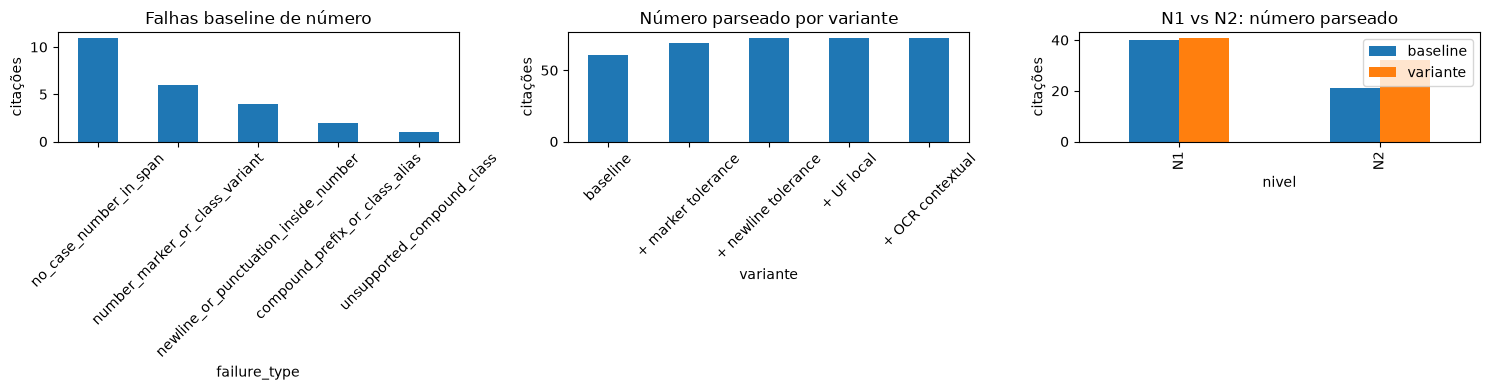

In [4]:
mechanisms = pd.DataFrame([
    {'mechanism': 'marker/class tolerance', 'numeros_recuperados': int(marginal.iloc[0]['+numeros']), 'UFs_recuperadas': 0, 'documentos': int(marginal.iloc[0].documentos), 'regressoes': 0, 'complexidade': 'LOW'},
    {'mechanism': 'newline/punctuation tolerance', 'numeros_recuperados': int(marginal.iloc[1]['+numeros']), 'UFs_recuperadas': 0, 'documentos': int(marginal.iloc[1].documentos), 'regressoes': 0, 'complexidade': 'LOW'},
    {'mechanism': 'UF local to number', 'numeros_recuperados': 0, 'UFs_recuperadas': int(marginal.iloc[2]['+UFs']), 'documentos': int(marginal.iloc[2].documentos), 'regressoes': 0, 'complexidade': 'LOW'},
    {'mechanism': 'OCR contextual O/0 l/1 S/5', 'numeros_recuperados': 0, 'UFs_recuperadas': 0, 'documentos': int(parsed_variants['+ OCR contextual'].loc[lambda frame: frame.numero_source.eq('ocr_repaired'), 'documento_id'].nunique()), 'regressoes': 0, 'complexidade': 'MEDIUM'},
])
display(mechanisms)
ocr_summary = pd.DataFrame([{'mechanism': 'O/0, l/1, S/5 dentro de candidato numérico', 'casos': int(parsed_variants['+ OCR contextual'].numero_source.eq('ocr_repaired').sum()), 'recuperados': int(parsed_variants['+ OCR contextual'].numero_source.eq('ocr_repaired').sum()), 'risco': 'MEDIUM / fallback local'}])
display(ocr_summary)

ocr_audit = best.loc[best.numero_source.eq('ocr_repaired'), ['documento_id', 'nivel', 'oracle_span', 'ocr_raw', 'numero_raw', 'numero_normalizado', 'numero_source']].copy()
display(ocr_audit if not ocr_audit.empty else pd.DataFrame({'OCR': ['Nenhum candidato contextual exigiu reparo']}))

audit_final = number_failures[['gold_idx', 'documento_id', 'nivel', 'failure_type']].merge(best[['gold_idx', 'numero_raw', 'numero_normalizado', 'uf_raw', 'uf', 'numero_source']], on='gold_idx', how='left')
audit_final = audit_final.merge(parsed_variants['baseline'][['gold_idx', 'numero_raw']].rename(columns={'numero_raw': 'baseline'}), on='gold_idx', how='left')
audit_final['structural_variant'] = audit_final.numero_source.eq('structurally_repaired')
audit_final['OCR_variant'] = audit_final.numero_source.eq('ocr_repaired')
audit_final['resultado'] = audit_final.numero_source.map({'structurally_repaired': 'recovered_structurally', 'ocr_repaired': 'repaired_contextually', 'missing': 'not_recovered'}).fillna('preserved')
display(audit_final[['documento_id', 'nivel', 'failure_type', 'baseline', 'structural_variant', 'OCR_variant', 'resultado', 'numero_source', 'numero_raw', 'uf']])

remaining = audit_final.loc[audit_final.resultado.eq('not_recovered')].groupby('failure_type').size().rename('quantidade').reset_index().rename(columns={'failure_type': 'reason'})
display(remaining)

level_rows = []
for level, group in numbered.groupby('nivel'):
    final_group = best.loc[best.nivel.eq(level)]
    level_rows.append({'nivel': level, 'numero baseline': f"{group.baseline_numero_normalizado.notna().sum()}/{len(group)}", 'numero variante': f"{final_group.numero_normalizado.notna().sum()}/{len(final_group)}", 'UF baseline': f"{group.baseline_uf.notna().sum()}", 'UF variante': f"{final_group.uf.notna().sum()}"})
level_comparison = pd.DataFrame(level_rows)
display(level_comparison)

searchability = pd.DataFrame({
    'profile': ['cnj_identifier', 'case_identifier', 'partial_or_contextual'],
    'baseline': [25, int(parsed_variants['baseline'].numero_normalizado.notna().sum()), int(parsed_variants['baseline'].numero_normalizado.isna().sum())],
    'best_variant': [25, int(best.numero_normalizado.notna().sum()), int(best.numero_normalizado.isna().sum())],
})
display(searchability)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
number_failure_summary.set_index('failure_type')['count'].plot.bar(ax=axes[0], title='Falhas baseline de número', ylabel='citações')
axes[0].tick_params(axis='x', rotation=45)
ablation.assign(numeros_n=ablation.numeros.str.split('/').str[0].astype(int)).set_index('variante')['numeros_n'].plot.bar(ax=axes[1], title='Número parseado por variante', ylabel='citações')
axes[1].tick_params(axis='x', rotation=45)
level_plot = pd.DataFrame({'baseline': numbered.groupby('nivel').baseline_numero_normalizado.count(), 'variante': best.groupby('nivel').numero_normalizado.count()})
level_plot.plot.bar(ax=axes[2], title='N1 vs N2: número parseado', ylabel='citações')
plt.tight_layout(); plt.show()

## 4. Decisão e desenho futuro

A recomendação abaixo é conceitual: nenhuma regra deste notebook é promovida a `src/`.

In [5]:
risk = pd.DataFrame([
    {'regra': 'marcador nº/n°/n. e aliases de classe', 'suporte': '8 recuperações em múltiplos documentos, N1/N2', 'complexidade': 'LOW', 'risco': 'LOW'},
    {'regra': 'newline/pontuação dentro de número', 'suporte': '4 recuperações em 4 documentos N2', 'complexidade': 'LOW', 'risco': 'LOW'},
    {'regra': 'UF somente na cauda do número', 'suporte': 'múltiplas variantes oficiais de UF', 'complexidade': 'LOW', 'risco': 'LOW'},
    {'regra': 'OCR contextual O/0, l/1, S/5', 'suporte': '2 identificadores N2 delimitados', 'complexidade': 'MEDIUM', 'risco': 'MODERATE: fallback local'},
    {'regra': 'ED-E-ED-RR composto', 'suporte': '1 caso em 1 documento', 'complexidade': 'HIGH', 'risco': 'HIGH / fora da V1'},
])
display(risk)

print('OCR recommendation: SOMENTE FALLBACK LOCAL — apenas dentro de candidato numérico delimitado, com numero_raw e numero_source preservados.')
print('Contrato revisado recomendado: ParsedCitation(family, tipo, tribunal_raw, tribunal, tribunal_source, data, provenance).')
print('data é um payload simples específico por família: processo {classe_raw, numero_raw, numero_normalizado, numero_family, numero_source, uf_raw, uf}; CNJ {numero_raw, numero_normalizado, numero_source}; e payloads análogos para súmula, lei e contexto.')
print('Estratégia: family recognition → family-specific parser → envelope ParsedCitation; sem regex universal e sem hierarquia OO extensa.')
print('Fora do parser: existência no corpus, real/inventada/incompleta, CaseIndex, id_canonico, desambiguação e decisão final de suficiência.')
print('Decisão: A) há evidência para implementar CitationParser V1, preservando OCR apenas como fallback contextual auditável.')
print('SHA-256 depois:', sha256_file(DB_PATH))

,regra,suporte,complexidade,risco
0,marcador nº/n°/n. e aliases de classe,"8 recuperações em múltiplos documentos, N1/N2",LOW,LOW
1,newline/pontuação dentro de número,4 recuperações em 4 documentos N2,LOW,LOW
2,UF somente na cauda do número,múltiplas variantes oficiais de UF,LOW,LOW
3,"OCR contextual O/0, l/1, S/5",2 identificadores N2 delimitados,MEDIUM,MODERATE: fallback local
4,ED-E-ED-RR composto,1 caso em 1 documento,HIGH,HIGH / fora da V1


OCR recommendation: SOMENTE FALLBACK LOCAL — apenas dentro de candidato numérico delimitado, com numero_raw e numero_source preservados.
Contrato revisado recomendado: ParsedCitation(family, tipo, tribunal_raw, tribunal, tribunal_source, data, provenance).
data é um payload simples específico por família: processo {classe_raw, numero_raw, numero_normalizado, numero_family, numero_source, uf_raw, uf}; CNJ {numero_raw, numero_normalizado, numero_source}; e payloads análogos para súmula, lei e contexto.
Estratégia: family recognition → family-specific parser → envelope ParsedCitation; sem regex universal e sem hierarquia OO extensa.
Fora do parser: existência no corpus, real/inventada/incompleta, CaseIndex, id_canonico, desambiguação e decisão final de suficiência.
Decisão: A) há evidência para implementar CitationParser V1, preservando OCR apenas como fallback contextual auditável.
SHA-256 depois: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
